## Análise de Componentes Principais (PCA): redução de dimensionalidade e análise exploratória dos descritores moleculares para identificar padrões e as variáveis mais influentes.
1. Importa o conjunto de dados contendo as features (descritores).

2. Padronização StandardScaler para normalizar os dados para garantir que todas as variáveis tenham a mesma escala antes da PCA.

3. Aplicação do PCA para projetar os dados em um espaço de menor dimensão.

4. Análise de Variância: Calcula e visualiza a variância explicada para determinar o número ideal de componentes.

5. Visualização do Espaço Latente: Plota os dados nos primeiros componentes principais (PC1 vs PC2) para observar agrupamentos (clusters) ou separações.

6. Análise de Loadings: Examina os pesos (loadings) de cada descritor original nos componentes principais para entender quais características químicas mais contribuem para a variância dos dados. 

### Importação das bibliotecas
Define quais variáveis vamos usar e carrega os dados

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import os

# Configuração estética 
sns.set_context("talk") 
plt.style.use('seaborn-v0_8-whitegrid')


### Carregamento e Pré-processamento

In [9]:
# 1. Configuração
work_features = ['HOMO', "GAP", "CV", 'Enthalpy', 'DETmax', 'CS']
file_path = "data_models_v1.xlsx - Sheet1.csv" # Nome do seu arquivo corrigido

# 2. Carregar Dados
try:
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    print("✅ Dataset carregado com sucesso!")
except FileNotFoundError:
    # Tenta buscar na pasta data se não achar na raiz
    df = pd.read_excel(r"../database/data/data_models_v1.xlsx")
    print("✅ Dataset carregado da pasta 'data'.")

# 3. Limpeza Crítica das Classes
# Remove espaços extras e padroniza tudo para Título (ex: "álcoois" -> "Álcoois")
df['classes_clean'] = df['classes'].astype(str).str.strip().str.title()

# Verificação Rápida
print(f"Total de Amostras: {len(df)}")
print(f"Variáveis Numéricas usadas: {work_features}")
print("-" * 30)
print("Top 5 Classes mais frequentes:")
print(df['classes_clean'].value_counts().head(5))

✅ Dataset carregado da pasta 'data'.
Total de Amostras: 152
Variáveis Numéricas usadas: ['HOMO', 'GAP', 'CV', 'Enthalpy', 'DETmax', 'CS']
------------------------------
Top 5 Classes mais frequentes:
classes_clean
Hidrocarbonetos Insaturados    12
Álcoois                        12
Fenóis E Derivados             12
Éteres                         12
Quinonas                       12
Name: count, dtype: int64


### Padronização e Execução da PCA

In [10]:
# 1. Padronização (Essencial: coloca todas variáveis na mesma régua)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[work_features])

# 2. Executar PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# 3. Consolidar Resultados
df_pca = df.copy()
df_pca['PC1'] = coords[:, 0]
df_pca['PC2'] = coords[:, 1]

# 4. Análise de Variância (O quanto o gráfico explica da realidade)
var_exp = pca.explained_variance_ratio_ * 100
total_var = sum(var_exp)

print(f"📊 Variância Explicada:")
print(f"   PC1: {var_exp[0]:.2f}% (Eixo X)")
print(f"   PC2: {var_exp[1]:.2f}% (Eixo Y)")
print(f"   TOTAL: {total_var:.2f}%")

📊 Variância Explicada:
   PC1: 62.68% (Eixo X)
   PC2: 20.97% (Eixo Y)
   TOTAL: 83.65%


### Lógica de Agrupamento (Clusters vs Outros)

In [11]:
# --- DEFINIÇÃO DOS GRUPOS ---

# 1. Identificar as Top N classes mais frequentes
top_n = 8
top_classes = df_pca['classes_clean'].value_counts().head(top_n).index.tolist()

# 2. GARANTIR que 'Sulfonamidas' esteja nos destaques (para validar seu texto)
# Busca qualquer classe que tenha "Sulfonamid" no nome
sulfonamida_tag = [c for c in df_pca['classes_clean'].unique() if 'Sulfonamid' in c]
if sulfonamida_tag:
    classe_sulf = sulfonamida_tag[0]
    if classe_sulf not in top_classes:
        top_classes.append(classe_sulf)
        print(f"🔹 Classe '{classe_sulf}' adicionada manualmente aos destaques.")

# 3. Criar coluna de Plotagem (Destaques vs Outros)
df_pca['Classe_Plot'] = df_pca['classes_clean'].apply(lambda x: x if x in top_classes else 'Outros')

# 4. Ordenar: "Outros" deve ser o primeiro a ser desenhado (ficar no fundo)
df_pca['sort_order'] = df_pca['Classe_Plot'].apply(lambda x: 0 if x == 'Outros' else 1)
df_pca = df_pca.sort_values('sort_order')

print("Classes que serão coloridas (Clusters):")
print([c for c in top_classes if c in df_pca['Classe_Plot'].unique()])

🔹 Classe 'Sulfonamidas E Derivados' adicionada manualmente aos destaques.
Classes que serão coloridas (Clusters):
['Hidrocarbonetos Insaturados', 'Álcoois', 'Fenóis E Derivados', 'Éteres', 'Quinonas', 'Ésteres De Ácidos Carboxílicos', 'Hidrocarbonetos Saturados', 'Anidridos De Ácido', 'Sulfonamidas E Derivados']


### Visualização dos clusteres

 Gráfico salvo em: C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


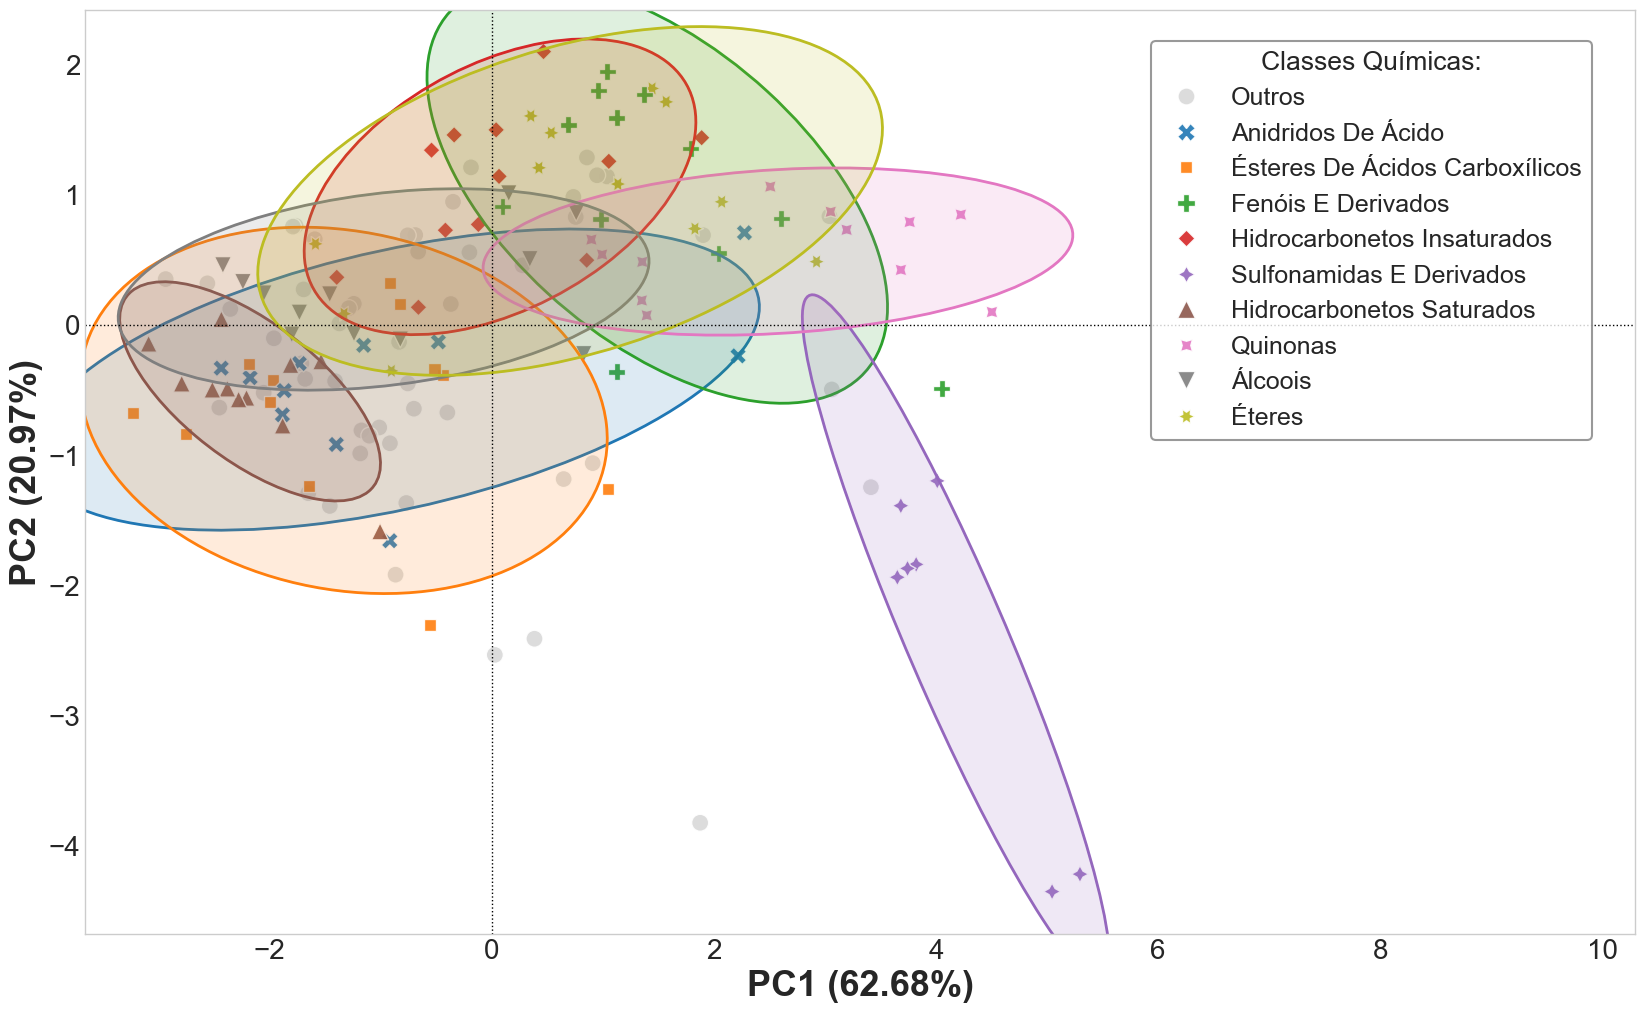

In [12]:
# --- FUNÇÃO AUXILIAR PARA ELIPSES ---
def draw_confidence_ellipse(x, y, ax, n_std=2.0, color='none', **kwargs):
    if x.size < 4: return # Ignora se tiver poucos pontos
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    # Cria a elipse
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      edgecolor=color, **kwargs)
    # Rotaciona e escala
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# --- PLOTAGEM ---
fig, ax = plt.subplots(figsize=(20, 12))

# 1. Definir Cores
unique_classes = [c for c in df_pca['Classe_Plot'].unique() if c != 'Outros']
palette = sns.color_palette("tab10", len(unique_classes)) # Cores vibrantes
color_dict = dict(zip(unique_classes, palette))
color_dict['Outros'] = '#d9d9d9' # Cinza claro para o fundo

# 2. Scatter Plot (Pontos)
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', 
    hue='Classe_Plot', style='Classe_Plot',
    palette=color_dict, s=150, alpha=0.9, ax=ax
)

# 3. Desenhar Elipses (Clusters)
for cls in unique_classes:
    data_cls = df_pca[df_pca['Classe_Plot'] == cls]
    cor = color_dict[cls]
    
    # Elipse Sombreada (Fundo do cluster)
    elipse = draw_confidence_ellipse(data_cls['PC1'], data_cls['PC2'], ax, n_std=2.0, color=cor)
    elipse.set_alpha(0.15) # Transparência leve
    elipse.set_facecolor(cor)
    
    # Elipse Contorno (Borda do cluster)
    draw_confidence_ellipse(data_cls['PC1'], data_cls['PC2'], ax, n_std=2.0, color=cor, linewidth=2, linestyle='-', facecolor='none')

# 4. Cosmética e Textos
ax.set_xlabel(f'PC1 ({var_exp[0]:.2f}%)', fontsize=26, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_exp[1]:.2f}%)', fontsize=26, fontweight='bold')
ax.tick_params(axis="x", labelsize=20)  # tamanho dos números no eixo x
ax.tick_params(axis="y", labelsize=20)  # tamanho dos números no eixo y
# 2. Expanda o limite do eixo X à direita para criar um espaço vazio para a legenda
x_limit_max = df_pca['PC1'].max()
ax.set_xlim(right=x_limit_max + 5) # Adiciona um respiro de 6 unidades à direita
#ax.set_title('Espaço Químico: Clusters de Classes e Sobreposições', fontsize=18, fontweight='bold', pad=20)

# Linhas de centro
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.grid(False) # Remove grade para limpar a visão das elipses

# Legenda Otimizada
#ax.legend(title='Classes Químicas', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=13, title_fontsize=14)
ax.legend(title='Classes Químicas:',
    loc='upper right',       # Fixa no topo direito do espaço extra
    bbox_to_anchor=(0.98, 0.98), # Ajuste fino para não encostar na borda
    fontsize=18, 
    title_fontsize=19,
    frameon=True, 
    facecolor='white', 
    edgecolor='gray')


# --- EXPORTAR ---
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
if not os.path.exists(caminho): os.makedirs(caminho)

fig.savefig(os.path.join(caminho, "PCA_Final_Clusters_V2.png"), dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(caminho, "PCA_Final_Clusters_V2.svg"), format='svg', bbox_inches='tight', facecolor='white')
print(f" Gráfico salvo em: {caminho}")

plt.show()

### Heatmap de loadings

✅ Matriz de Loadings salva com sucesso em:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


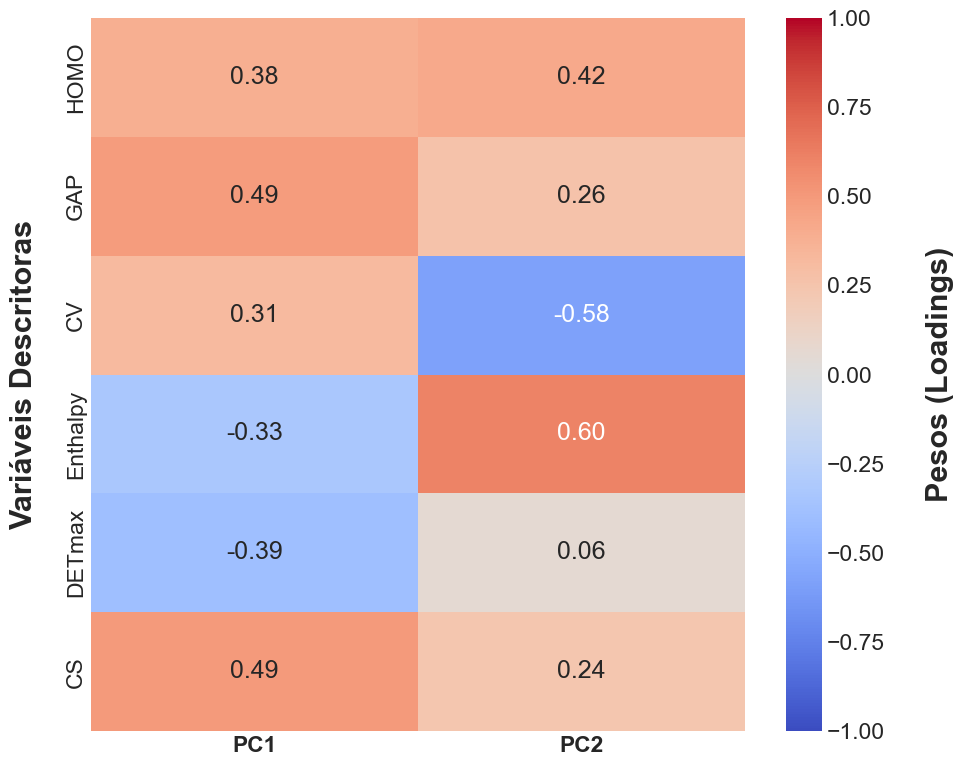

Interpretação:
-> Valores próximos de +1 ou -1 indicam forte influência.
-> Valores próximos de 0 indicam que a variável não afeta aquele eixo.


In [13]:

import seaborn as sns

# 1. Extrair os pesos (Loadings) da PCA já calculada
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=work_features
)

# 2. Plotar Heatmap
fig_load, ax_load = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f", vmin=-1, vmax=1, ax=ax_load)
ax.collections[0].colorbar.set_label('Pesos (Loadings)', fontweight='bold', labelpad=30, fontsize=22)   #negirto e distanciamento do eixo

ax.set_ylabel("Variáveis Descritoras", fontsize=22, fontweight='bold', labelpad=20)   #labelpad afasta o eixo y do grafico
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')


            

# --- BLOCO DE EXPORTAÇÃO EM ALTA QUALIDADE ---
name_arq = "PCA_Loadings_Heatmap"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"

# 1. Salvar PNG (Alta Resolução para Word/PowerPoint)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig_load.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (Vetorial para edição sem perda de qualidade)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig_load.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')
print(f"✅ Matriz de Loadings salva com sucesso em:\n{caminho}")

plt.tight_layout()
plt.show()

print("Interpretação:")
print("-> Valores próximos de +1 ou -1 indicam forte influência.")
print("-> Valores próximos de 0 indicam que a variável não afeta aquele eixo.")

### Equação PC1 e PC2

In [14]:
import pandas as pd

# work_features = lista de nomes das features (como no seu heatmap)
cols = list(work_features)

loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

def eq_padronizada(k, top=None):
    s = loadings.iloc[:, k].copy()
    if top:
        s = s.reindex(s.abs().sort_values(ascending=False).index).head(top)
    termos = [f"({coef:+.6f})*z[{name}]" for name, coef in s.items()]
    return " ".join(termos).replace("+ -", "- ")

print("PC1 (padronizada):")
print("PC1 =", eq_padronizada(0, top=30))

print("\nPC2 (padronizada):")
print("PC2 =", eq_padronizada(1, top=30))

PC1 (padronizada):
PC1 = (+0.494481)*z[CS] (+0.491327)*z[GAP] (-0.394894)*z[DETmax] (+0.383965)*z[HOMO] (-0.334885)*z[Enthalpy] (+0.313955)*z[CV]

PC2 (padronizada):
PC2 = (+0.601835)*z[Enthalpy] (-0.579683)*z[CV] (+0.415291)*z[HOMO] (+0.264488)*z[GAP] (+0.236617)*z[CS] (+0.057914)*z[DETmax]


### VALIDANDO A CORRELAÇÃO COM O ALVO

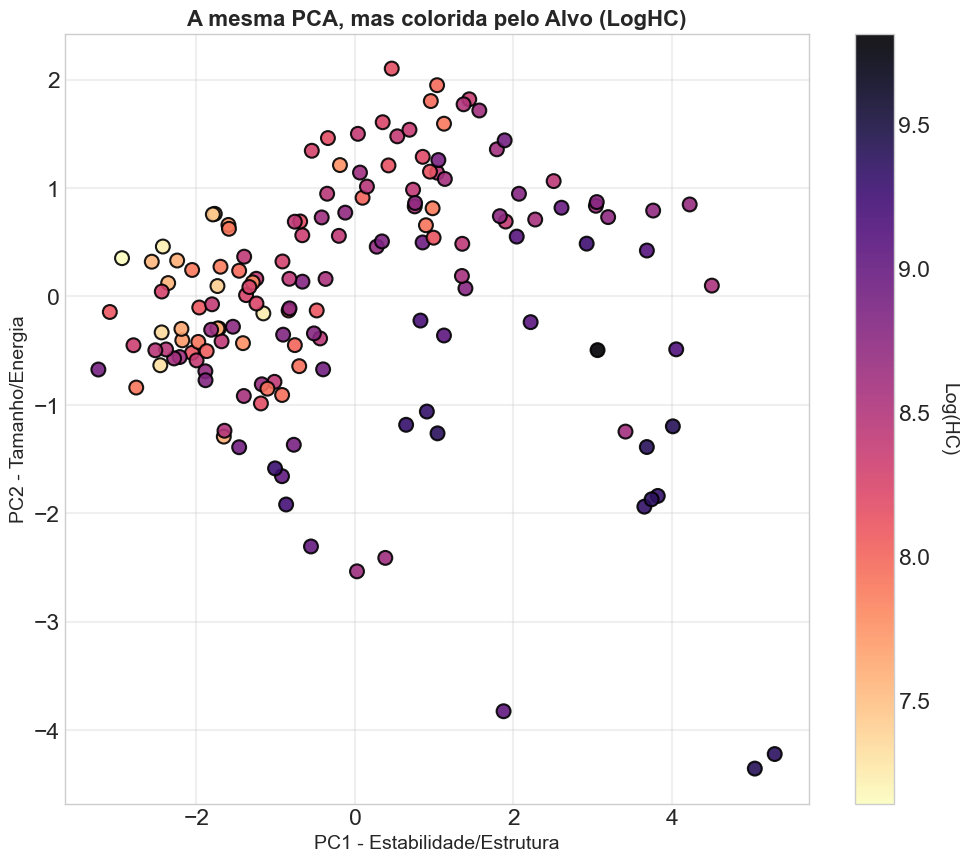

INTERPRETAÇÃO:
Se houver um gradiente de cor (ex: claro num canto, escuro no outro),
significa que seus descritores conseguem prever o alvo naturalmente!


In [15]:

# Aqui NÃO recalculamos a PCA. Usamos a mesma (só descritores).
# Apenas pintamos os pontos pelo LogHeatOfCombustion para ver a tendência visual.

fig, ax = plt.subplots(figsize=(12, 10))

# Plot usando LogHeatOfCombustion como cor (hue)
sc = ax.scatter(
    df_pca['PC1'], df_pca['PC2'], 
    c=df_pca['LogHeatOfCombustion'], 
    cmap='magma_r', # Cor quente = Alto calor
    s=100, alpha=0.9, edgecolors='k'
)

# Barra de cores
cbar = plt.colorbar(sc)
cbar.set_label('Log(HC)', fontsize=14, rotation=270, labelpad=20)

ax.set_xlabel(f'PC1 - Estabilidade/Estrutura', fontsize=14)
ax.set_ylabel(f'PC2 - Tamanho/Energia', fontsize=14)
ax.set_title('A mesma PCA, mas colorida pelo Alvo (LogHC)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.show()

print("INTERPRETAÇÃO:")
print("Se houver um gradiente de cor (ex: claro num canto, escuro no outro),")
print("significa que seus descritores conseguem prever o alvo naturalmente!")